In [1]:
# Barplot per site averaged over years

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))
from config1 import MONITORING_DATA, color_mapping, site_order, class_it_mapping, fig_class_order

In [ ]:
p_csv= MONITORING_DATA /"Tables_PollenCounts/"
pperc = p_csv / "1.generated_tables/percentages_all.csv"

p_save_fig = MONITORING_DATA / "Figures_Values/"


p_figtables= MONITORING_DATA /"4.Tables_for_figures/"


In [22]:
all_years = [2019, 2020, 2021, 2022, 2023]

list_ticks_order = [
    '$\\it{Quercus~deciduous}$', '$\\it{Quercus~ilex}$', '$\\it{Buxus}$', '$\\it{Phillyrea}$',
    '$\\it{Fraxinus}$', '$\\it{Olea}$', 'Cupressaceae', '$\\it{Pistacia}$', 'Poaceae',
    '$\\it{Plantago}$', '$\\it{Vitis}$ fertile', '$\\it{Vitis}$ sterile', 'Pinaceae', 'Non-target taxa',]

numbered_labels = [f"{i+1}: {label}" for i, label in enumerate(list_ticks_order)]



In [23]:
df_pollen = pd.read_csv(pperc)
df_pollen.head()


,class,site,year,site_year,class_num,count,proportion
0,Buxus,D1,2019,D1_2019,2,53.806745,6.734485
1,Buxus,D1,2020,D1_2020,2,41.644678,1.226623
2,Buxus,D1,2021,D1_2021,2,24.990120,1.016147
3,Buxus,D2,2020,D2_2020,2,27.706941,0.795045
4,Buxus,D2,2021,D2_2021,2,30.323475,0.712326


In [24]:
df_pollen = df_pollen.drop(['year', "proportion"], axis=1)

df_pollen_allsites =  df_pollen[["class", "class_num", "count"]].groupby(["class", "class_num",]).mean().reset_index()
df_pollen_allsites["site"] = "all sites"
df_pollen_site = pd.concat([df_pollen, df_pollen_allsites], ignore_index=True)
df_pollen_site

,class,site,site_year,class_num,count
0,Buxus,D1,D1_2019,2,53.806745
1,Buxus,D1,D1_2020,2,41.644678
2,Buxus,D1,D1_2021,2,24.990120
3,Buxus,D2,D2_2020,2,27.706941
4,Buxus,D2,D2_2021,2,30.323475
...,...,...,...,...,...
401,Poaceae,all sites,NaN,8,362.452916
402,QuercusDeciduous,all sites,NaN,0,176.731426
403,QuercusIlex,all sites,NaN,1,642.716096
404,VitisF,all sites,NaN,10,312.899947


In [25]:
# mean over years per site
df_pollen_site_perc = df_pollen_site[["class", "site","class_num", "count"]].groupby(["class", "site"]).mean().reset_index()

df_pollen_site_perc.loc[:, "percentage"] = df_pollen_site_perc["count"] * 100 / df_pollen_site_perc.groupby(["site"])["count"].transform("sum")

df_pollen_site_perc

,class,site,class_num,count,percentage
0,Buxus,D1,2.0,40.147181,1.810241
1,Buxus,D2,2.0,33.445525,0.584896
2,Buxus,D3,2.0,66.256590,0.672984
3,Buxus,W1,2.0,98.524399,1.976022
4,Buxus,W2,2.0,18.785999,0.468297
...,...,...,...,...,...
107,VitisS,W1,11.0,22.589214,0.453053
108,VitisS,W2,11.0,38.755929,0.966107
109,VitisS,W3,11.0,18.431962,0.510487
110,VitisS,W4,11.0,315.585040,2.742719


In [26]:
df_wide = df_pollen_site_perc.pivot(index="site", columns="class", values="percentage").reset_index()
df_wide.columns.name = None

df_wide.set_index('site', inplace=True)


df_wide = df_wide[fig_class_order]

df_wide.reset_index()

li_index = ["all sites", "D3", "D2",  "D1","W4",  "W3","W2", "W1"]
df_wide = df_wide.reindex(li_index)
print(df_wide.sum(axis=1))


df_wide

site
all sites    100.0
D3           100.0
D2           100.0
D1           100.0
W4           100.0
W3           100.0
W2           100.0
W1           100.0
dtype: float64


,QuercusDeciduous,QuercusIlex,Buxus,Phillyrea,Fraxinus,Olea,Cupressaceae,Pistacia,Poaceae,Plantago,VitisF,VitisS,Pinaceae,Other
site,,,,,,,,,,,,,,
all sites,2.977812,10.829357,3.560370,6.733015,10.248280,3.335417,7.896067,4.065801,6.107101,2.104918,5.272165,1.533565,7.796139,27.539992
D3,3.164701,7.171234,0.672984,0.573871,0.686101,2.302566,11.144105,5.454368,4.772417,1.945520,14.397280,1.731322,8.773110,37.210420
D2,2.057375,6.742203,0.584896,0.781138,1.122160,1.285570,9.699756,4.808847,22.721990,8.052289,1.282975,0.841318,11.501869,28.517614
D1,3.323174,11.788805,1.810241,1.487896,1.662753,2.185227,17.064335,13.675592,6.166938,1.493598,1.494005,0.852778,9.640222,27.354435
W4,2.416605,6.695982,2.289755,8.830898,20.532423,3.564419,8.383740,4.010579,3.909053,1.100459,1.721939,2.742719,6.155348,27.646084
W3,2.342620,10.017698,25.105839,11.330886,10.786858,3.639923,3.479011,1.433046,1.817495,0.619223,1.501112,0.510487,6.598212,20.817590
W2,5.627615,36.455096,0.468297,0.471275,0.384234,0.899186,6.721677,3.017415,3.282047,1.216133,4.714213,0.966107,8.145778,27.630925
W1,3.113674,6.603816,1.976022,15.991210,12.356436,7.594074,3.607374,2.218827,1.731948,0.831160,13.559745,0.453053,7.331582,22.631080


In [27]:
df_wide = df_pollen_site_perc.pivot(index="site", columns="class", values="percentage").reset_index()
df_wide.columns.name = None

df_wide.set_index('site', inplace=True)


df_wide = df_wide[fig_class_order]

df_wide.reset_index()

li_index = ["all sites", "D3", "D2",  "D1","W4",  "W3","W2", "W1"]
df_wide = df_wide.reindex(li_index)
print(df_wide.sum(axis=1))


df_wide

site
all sites    100.0
D3           100.0
D2           100.0
D1           100.0
W4           100.0
W3           100.0
W2           100.0
W1           100.0
dtype: float64


,QuercusDeciduous,QuercusIlex,Buxus,Phillyrea,Fraxinus,Olea,Cupressaceae,Pistacia,Poaceae,Plantago,VitisF,VitisS,Pinaceae,Other
site,,,,,,,,,,,,,,
all sites,2.977812,10.829357,3.560370,6.733015,10.248280,3.335417,7.896067,4.065801,6.107101,2.104918,5.272165,1.533565,7.796139,27.539992
D3,3.164701,7.171234,0.672984,0.573871,0.686101,2.302566,11.144105,5.454368,4.772417,1.945520,14.397280,1.731322,8.773110,37.210420
D2,2.057375,6.742203,0.584896,0.781138,1.122160,1.285570,9.699756,4.808847,22.721990,8.052289,1.282975,0.841318,11.501869,28.517614
D1,3.323174,11.788805,1.810241,1.487896,1.662753,2.185227,17.064335,13.675592,6.166938,1.493598,1.494005,0.852778,9.640222,27.354435
W4,2.416605,6.695982,2.289755,8.830898,20.532423,3.564419,8.383740,4.010579,3.909053,1.100459,1.721939,2.742719,6.155348,27.646084
W3,2.342620,10.017698,25.105839,11.330886,10.786858,3.639923,3.479011,1.433046,1.817495,0.619223,1.501112,0.510487,6.598212,20.817590
W2,5.627615,36.455096,0.468297,0.471275,0.384234,0.899186,6.721677,3.017415,3.282047,1.216133,4.714213,0.966107,8.145778,27.630925
W1,3.113674,6.603816,1.976022,15.991210,12.356436,7.594074,3.607374,2.218827,1.731948,0.831160,13.559745,0.453053,7.331582,22.631080


### The file used to plot the figure is also available in the ZENODO repository : 


In [ ]:

df_wide=pd.read_csv(p_figtables / "table_fig4a_perc_perSite.csv" )


/tmp/ipykernel_17009/752243583.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([0,20,40,60,80,100], fontsize=13)


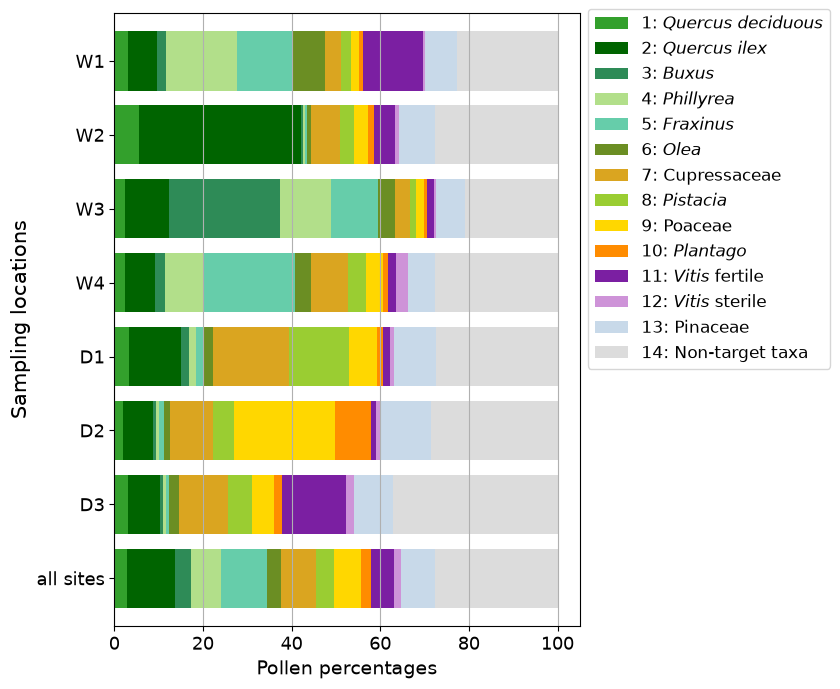

In [30]:
colors = [color_mapping[class_name] for class_name in list(df_wide.columns)]

fig, ax = plt.subplots(figsize=(8.5, 7))
ax = df_wide.plot(kind='barh', stacked=True, ax=ax,color=colors,  width=0.8)

plt.xlabel('Pollen percentages', fontsize=14)
plt.ylabel('Sampling locations',  fontsize=15)

ax.set_yticklabels(df_wide.index, fontsize=13)
ax.set_xticklabels([0,20,40,60,80,100], fontsize=13)

plt.title('')
plt.legend(title='', labels=numbered_labels, bbox_to_anchor=(1, 1.02), loc='upper left', ncol = 1, fontsize=12)
plt.grid(True, axis='x')
plt.tight_layout()

#plt.savefig(p_save_fig/"percpersite_all_percentages.pdf", bbox_inches="tight")
#plt.savefig(p_save_fig/"percpersite_all_percentages.svg",  format="svg", bbox_inches="tight")
plt.tight_layout()
plt.show()

# per site and year

In [34]:
df_pollen = pd.read_csv(pperc)
df_pollen["class_it"] = [class_it_mapping[el] for el in df_pollen["class"]]
df_pollen=df_pollen.drop(columns="site_year")
df_pollen.head()


,class,site,year,class_num,count,proportion,class_it
0,Buxus,D1,2019,2,53.806745,6.734485,$\it{Buxus}$
1,Buxus,D1,2020,2,41.644678,1.226623,$\it{Buxus}$
2,Buxus,D1,2021,2,24.990120,1.016147,$\it{Buxus}$
3,Buxus,D2,2020,2,27.706941,0.795045,$\it{Buxus}$
4,Buxus,D2,2021,2,30.323475,0.712326,$\it{Buxus}$


In [35]:
df_pollen_allyears = (df_pollen.groupby(["site", "class", "class_it", "class_num"]).mean().reset_index())

df_pollen_allyears["year"] = "all years"

df_pollen_years = pd.concat(
    [df_pollen, df_pollen_allyears],
    ignore_index=True
)
df_pollen_years

,class,site,year,class_num,count,proportion,class_it
0,Buxus,D1,2019,2,53.806745,6.734485,$\it{Buxus}$
1,Buxus,D1,2020,2,41.644678,1.226623,$\it{Buxus}$
2,Buxus,D1,2021,2,24.990120,1.016147,$\it{Buxus}$
3,Buxus,D2,2020,2,27.706941,0.795045,$\it{Buxus}$
4,Buxus,D2,2021,2,30.323475,0.712326,$\it{Buxus}$
...,...,...,...,...,...,...,...
485,Poaceae,W4,all years,8,449.786793,3.904169,Poaceae
486,QuercusDeciduous,W4,all years,0,278.061471,3.614641,$\it{Quercus}$ $\it{deciduous}$
487,QuercusIlex,W4,all years,1,770.458805,9.408064,$\it{Quercus}$ $\it{ilex}$
488,VitisF,W4,all years,10,198.131179,1.467997,$\it{Vitis}$ fertile


### The file used to plot the figure is also available in the ZENODO repository : 


In [ ]:
# saving intermediary table used for the figure
df_pollen_years = pd.read_csv(p_figtables / "table_fig5a_perc_persite_peryear.csv")


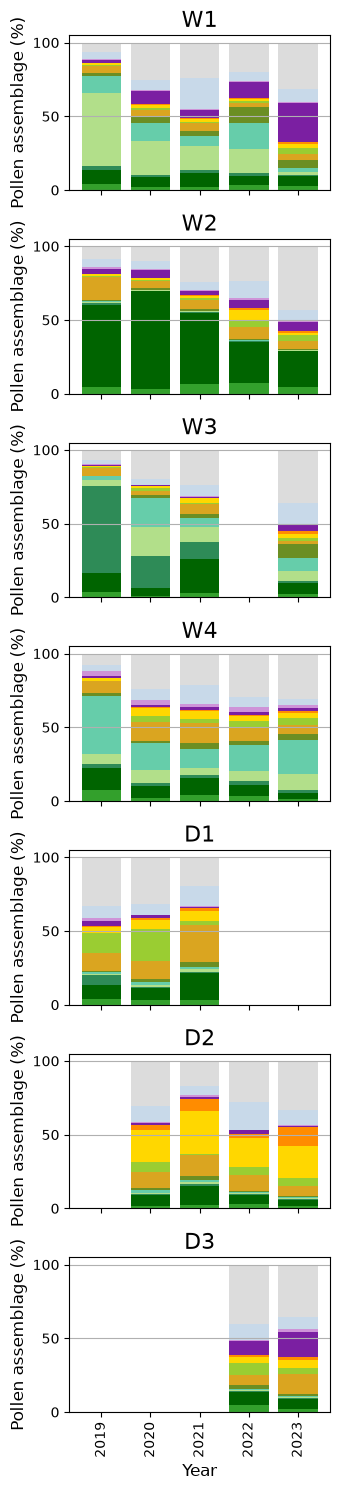

In [ ]:

df_pollen_years1 = df_pollen_years[df_pollen_years["year"]!= "all years"]

n_sites = len(site_order)
n_cols = 1
n_rows = 7 

fig, axes = plt.subplots(n_rows, n_cols,figsize=(3.5, 15),sharex=True, sharey=True)
axes = axes.flatten()

for e, (sitei, ax) in enumerate(zip(site_order, axes)):

    dffig = df_pollen_years1[df_pollen_years1["site"] == sitei]

    df_pivot = dffig.pivot_table(index='year',columns='class',values='proportion',fill_value=0)
    df_pivot = df_pivot.reindex(index=all_years,columns=fig_class_order,fill_value=0)

    plot_colors = [color_mapping[class_name]for class_name in df_pivot.columns]

    df_pivot.plot(kind='bar',stacked=True,color=plot_colors,ax=ax,legend=False,edgecolor='none',linewidth=0,width=0.8)
    ax.invert_yaxis()
    ax.set_title(f'{sitei}',fontsize=16)

    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Pollen assemblage (%)', fontsize=12)


    ax.set_yticks([0, 50, 100])
    ax.set_yticklabels(['0', '50', '100'], fontsize=12)

    ax.invert_yaxis()

    ax.grid(True, axis='y')
    

    ax.set_xticklabels(all_years, rotation=90, fontsize=10)
    ax.tick_params(axis='y', labelsize=10)
    #plt.legend(title='', labels=numbered_labels, bbox_to_anchor=(1, 0), loc='lower left', ncol = 4, fontsize=12)


fig.tight_layout()
# plt.savefig(p_save_fig+"percentages_perSiteYear.pdf", bbox_inches="tight")
plt.show()



In [ ]:
# end